In [1]:
import pandas as pd
from tokenizers import Tokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt

In [8]:
import pandas as pd
import pyarrow.parquet as pq
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
import os
from tqdm import tqdm
import math
import gc
import numpy as np

# ============================================================
# CONFIGURAÇÕES
# ============================================================
TSV_PATH = '/media/alvarinho/dados/Datasets/refined/traducao/analise_textos.tsv'
SPLIT_PARQUET_PATH = '/media/alvarinho/dados/Datasets/refined/traducao/analise_textos_split.parquet'

# ============================================================
# FUNÇÕES DE LEITURA E PREPARAÇÃO
# ============================================================
def load_train_indices(parquet_path, batch_size=1_000_000, target_sample_size=1_000_000):
    print('Carregando metadados de split em lotes...')
    parquet_file = pq.ParquetFile(parquet_path)
    
    # Dicionário temporário para guardar arrays numéricos, que são muito leves
    train_indices = {}
    split_counts = {}
    
    total_linhas = parquet_file.metadata.num_rows
    
    # Lemos APENAS as 3 colunas necessárias para o sorteio, poupando muita RAM e CPU
    with tqdm(total=total_linhas, desc='Mapeando indices', unit='linhas') as pbar:
        for batch in parquet_file.iter_batches(
            batch_size=batch_size, 
            columns=['dataset_id', 'index', 'split']
        ):
            linhas_neste_lote = batch.num_rows 
            df_chunk = batch.to_pandas()
            
            # Contagem global
            counts = df_chunk['split'].value_counts().to_dict()
            for split_name, count in counts.items():
                split_counts[split_name] = split_counts.get(split_name, 0) + count
                
            # Filtra apenas o split de treino
            df_train = df_chunk[df_chunk['split'] == 'train']
            
            # Agrupa e guarda os arrays do numpy
            for dataset_id, group in df_train.groupby('dataset_id', observed=True):
                if dataset_id not in train_indices:
                    train_indices[dataset_id] = []
                
                train_indices[dataset_id].append(group['index'].values)
                
            del df_chunk
            del df_train
            gc.collect()
            
            pbar.update(linhas_neste_lote)

            total_train_indices = sum(
                arr.size
                for arrays in train_indices.values()
                for arr in arrays
            )
            if total_train_indices >= target_sample_size:
                break
            
    return train_indices

In [9]:
def get_text_iterator(tsv_path, train_indices, batch_size=10000):
    """
    Lê o arquivo TSV linha por linha, faz o split pelas marcações,
    injeta a tag de tradução no texto de origem e yield dos textos.
    """
    batch = []
    
    with open(tsv_path, 'r', encoding='utf-8') as f:
        
        for line in f:
            line = line.rstrip('\n')
            
            try:
                meta_part, texts_part = line.split('<METADATA>')
                dataset_id, idx_str = meta_part.split('<SEP>')
                text1, text2 = texts_part.split('<SEP>')
                
                    
                # ====================================================
                # INJEÇÃO DA TAG DE TRADUÇÃO (Approach 1)
                # ====================================================
                # Verifica o sufixo do dataset_id para saber a direção[cite: 2]
                if dataset_id.endswith('_en_pt'):
                    text1_modificado = f"<2pt> {text1}"
                elif dataset_id.endswith('_en_es'):
                    text1_modificado = f"<2es> {text1}"
                else:
                    text1_modificado = text1 # Fallback de segurança
                    
                # Adiciona o texto em inglês (com a tag) e o texto alvo ao lote
                batch.extend([text1_modificado, text2])
                
                if len(batch) >= batch_size:
                    yield batch
                    batch = []
                    
            except ValueError:
                # Passa silenciosamente por linhas mal formatadas
                continue
                
    if batch:
        yield batch


In [10]:
indices = load_train_indices(SPLIT_PARQUET_PATH)

Carregando metadados de split em lotes...


Mapeando indices:   4%|▍         | 2000000/51615665 [00:00<00:05, 8692966.13linhas/s]


In [11]:
import pandas as pd
from tqdm import tqdm

iterator_train = get_text_iterator(TSV_PATH, indices, batch_size=1)

# Usamos uma lista simples para armazenar os dados temporariamente
data = []

# Um único tqdm é suficiente
for batch in tqdm(iterator_train, total=1_000_000, desc='Mapeando indices', unit='linhas'):
    # Salvamos como uma tupla, que é leve e rápida
    data.append((batch[0], 'src'))
    data.append((batch[1], 'tgt'))
    if len(data) == 2_000_000:
        break

# Criamos o DataFrame de uma vez só no final (MUITO mais rápido)
df_train = pd.DataFrame(data, columns=['lang', 'type'])

Mapeando indices: 100%|█████████▉| 999999/1000000 [00:01<00:00, 523021.50linhas/s]


In [12]:
df_train.head()

,lang,type
0,<2es> EUROPEAN PUBLIC ASSESSMENT REPORT (EPAR),src
1,INFORME PÚBLICO EUROPEO DE EVALUACIÓN (EPAR),tgt
2,<2es> EPAR summary for the public,src
3,Resumen del EPAR para el público general,tgt
4,<2es> This document is a summary of the Europe...,src


In [80]:
tokenizer = Tokenizer.from_file('artifacts/tokenizer_en_pt_es_30000.json')

In [81]:
tokenizer.encode('Olá mundo, meu nome é João').tokens

['<BOS>',
 'Ol',
 'á</w>',
 'mundo</w>',
 ',</w>',
 'meu</w>',
 'nome</w>',
 'é</w>',
 'João</w>',
 '<EOS>']

In [82]:
tokenizer.encode('Olá mundo, meu nome é João').ids

[5, 8864, 2696, 5569, 2661, 13699, 11483, 2707, 24423, 6]

In [83]:
tokenizer.decode(tokenizer.encode('Olá mundo, meu nome é João').ids)

'Olá mundo , meu nome é João'

In [86]:
df_train['lang_length'] = df_train['lang'].str.len()

In [14]:
df_train.head()

,lang,type,len_tokens_30000
0,<2es> EUROPEAN PUBLIC ASSESSMENT REPORT (EPAR),src,22
1,INFORME PÚBLICO EUROPEO DE EVALUACIÓN (EPAR),tgt,20
2,<2es> EPAR summary for the public,src,9
3,Resumen del EPAR para el público general,tgt,10
4,<2es> This document is a summary of the Europe...,src,19


In [15]:
vocabs_sizes = [30_000, 50_000, 60_000, 120_000, 150_000, 180_000, 200_000]

print('Declaring tokenizer...')
for vocab_size in tqdm(vocabs_sizes):
    tokenizer = Tokenizer.from_file(f'artifacts/tokenizer_en_pt_es_{vocab_size}.json')
    
    df_train[f'len_tokens_{vocab_size}'] = df_train['lang'].apply(lambda x: len(tokenizer.encode(x).ids))
    df_train['lang_length'] = df_train['lang'].str.len()

    df_train[f'compress_{vocab_size}'] = df_train.apply(lambda x: x[f'len_tokens_{vocab_size}'] / x['lang_length'], axis=1)

Declaring tokenizer...


100%|██████████| 7/7 [06:45<00:00, 57.97s/it]


In [21]:
columns_compress = [x for x in df_train.columns if 'compress' in x]
rename_columns = {x: x.replace('compress_', '') for x in columns_compress}
df_stats = df_train[columns_compress].rename(columns=rename_columns).describe().style.format("{:,.2%}")
df_stats

,30000,50000,60000,120000,150000,180000,200000
count,"200,000,000.00%","200,000,000.00%","200,000,000.00%","200,000,000.00%","200,000,000.00%","200,000,000.00%","200,000,000.00%"
mean,27.94%,25.30%,24.61%,24.62%,24.31%,24.11%,24.02%
std,8.07%,7.17%,6.78%,7.43%,7.36%,7.32%,7.31%
min,13.59%,9.71%,9.71%,9.00%,9.00%,9.00%,9.00%
25%,22.94%,21.05%,20.54%,20.00%,19.73%,19.54%,19.47%
50%,26.00%,23.64%,23.08%,22.67%,22.33%,22.14%,22.05%
75%,30.38%,27.27%,26.67%,26.83%,26.53%,26.32%,26.17%
max,300.00%,300.00%,300.00%,300.00%,300.00%,300.00%,300.00%


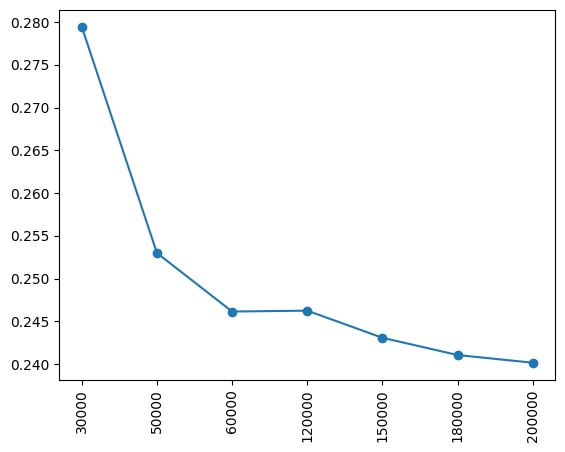

In [17]:
df_stats.T['mean'].plot.line(marker='o')
plt.xticks(rotation=90)
plt.show()

In [27]:
columns_tokens = [x for x in df_train.columns if 'len_tokens_' in x]
df_train[columns_tokens].describe(percentiles=[0.25, .5, .75, .8,.9, .95, .99, .999]).style.format("{:,.0f}")

,len_tokens_30000,len_tokens_50000,len_tokens_60000,len_tokens_120000,len_tokens_150000,len_tokens_180000,len_tokens_200000
count,"2,000,000","2,000,000","2,000,000","2,000,000","2,000,000","2,000,000","2,000,000"
mean,26,24,23,23,22,22,22
std,19,17,16,15,15,14,14
min,3,3,3,3,3,3,3
25%,14,12,12,12,12,12,12
50%,22,20,20,19,19,19,19
75%,34,31,30,29,29,28,28
80%,37,34,33,32,31,31,31
90%,48,44,43,40,40,39,39
95%,59,54,52,49,48,48,47


In [29]:
df_train[df_train['len_tokens_60000'] > 50].sort_values(by='len_tokens_60000', ascending=False)

,lang,type,len_tokens_30000,lang_length,compress_30000,len_tokens_50000,compress_50000,len_tokens_60000,compress_60000,len_tokens_120000,compress_120000,len_tokens_150000,compress_150000,len_tokens_180000,compress_180000,len_tokens_200000,compress_200000
724191,Poco frecuentes (afectan a entre 1 y 10 de cad...,tgt,838,3232,0.259282,725,0.224319,714,0.220916,646,0.199876,630,0.194926,629,0.194616,623,0.192760
686717,2 • Información de referencia breve acerca de ...,tgt,732,3522,0.207836,681,0.193356,662,0.187961,617,0.175185,589,0.167235,582,0.165247,580,0.164679
724190,<2es> 110 Uncommon (affects 1 to 10 users in 1...,src,646,2759,0.234143,594,0.215295,576,0.208771,531,0.192461,525,0.190286,523,0.189561,521,0.188837
694405,Frecuentes: dolor de cabeza ictericia ocular (...,tgt,661,2432,0.271793,571,0.234786,551,0.226562,478,0.196546,471,0.193668,460,0.189145,456,0.187500
468461,Raros (en más de 1 de cada 10.000 pacientes pe...,tgt,658,2666,0.246812,560,0.210053,543,0.203676,507,0.190173,498,0.186797,495,0.185671,494,0.185296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615731,Estos efectos indeseables mediados farmacológi...,tgt,64,289,0.221453,52,0.179931,51,0.176471,47,0.162630,46,0.159170,46,0.159170,46,0.159170
328,<2es> Hyperglycaemia and Diabetes Mellitus: hy...,src,58,238,0.243697,53,0.222689,51,0.214286,43,0.180672,43,0.180672,42,0.176471,41,0.172269
520512,<2es> Such reactions to insulin (including ins...,src,56,224,0.250000,52,0.232143,51,0.227679,48,0.214286,47,0.209821,46,0.205357,46,0.205357
520463,"Además, bajo la influencia de medicamentos sim...",tgt,60,206,0.291262,55,0.266990,51,0.247573,43,0.208738,42,0.203883,40,0.194175,40,0.194175
